# 04_01 - Model 3 Comparison and Final Export

The closing notebook for Model 3 (XGBoost Regressor + XGBoost Classifier): both models trained fresh here on the same 3 expanding-window folds, their results consolidated side by side, and the final prediction tables exported in the exact schema the team agreed on for comparing all 4 teammates' models.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parents[1] / "src"))

import pandas as pd
import matplotlib.pyplot as plt
from common.folds import FOLDS, split_fold
from common.labeling import compute_peak_thresholds
from common.metrics import (
    forecast_metrics,
    forecast_metrics_by_horizon,
    peak_risk_metrics,
    top_k_capture_rate,
    calibration_data,
    pr_curve_data,
)
from forecast.XGBoost_Regressor import build_training_table as build_regressor_table, train_and_predict as regressor_predict
from peak_risk.XGBoost_Classifier import build_training_table as build_classifier_table, train_and_predict as classifier_predict

DATA_PATH = Path.cwd().parents[1] / "data" / "interim" / "fsa_hourly_master.parquet"
df = pd.read_parquet(DATA_PATH)

regressor_table = build_regressor_table(df)
classifier_table = build_classifier_table(df)
print("regressor table shape:", regressor_table.shape)
print("classifier table shape:", classifier_table.shape)

regressor table shape: (262800, 67)
classifier table shape: (6307200, 23)


## 1. Regressor - forecasting

Re-trained here from scratch on the 3 folds, same design as `02_04_xgboost_regressor_training.ipynb` - this notebook is meant to stand on its own as the final summary, not assume the reader already opened the earlier ones.

In [2]:
regressor_results = {}
for fold_name, train_df, test_df in ((f, *split_fold(regressor_table, f)) for f in FOLDS):
    regressor_results[fold_name] = regressor_predict(train_df, test_df)
    print(f"{fold_name} done - {len(regressor_results[fold_name])} rows")

regressor_summary = pd.DataFrame({
    fold_name: forecast_metrics(results["actual"], results["prediction"])
    for fold_name, results in regressor_results.items()
}).T
regressor_summary

fold_1 done - 1261440 rows


fold_2 done - 1264896 rows


fold_3 done - 1257984 rows


,mae,wape,rmse,mape
fold_1,1096.411928,0.121477,1947.819988,10.135913
fold_2,557.408276,0.060764,891.813461,5.969134
fold_3,613.562168,0.063488,1032.389133,5.965348


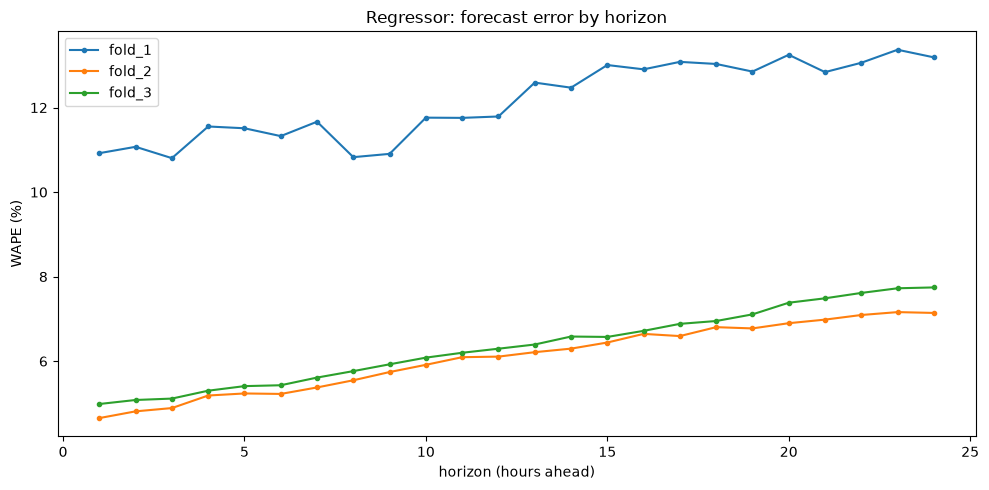

In [3]:
regressor_by_horizon = {fold_name: forecast_metrics_by_horizon(results) for fold_name, results in regressor_results.items()}

fig, ax = plt.subplots(figsize=(10, 5))
for fold_name, metrics_df in regressor_by_horizon.items():
    ax.plot(metrics_df.index, metrics_df["wape"] * 100, marker="o", markersize=3, label=fold_name)
ax.set_xlabel("horizon (hours ahead)")
ax.set_ylabel("WAPE (%)")
ax.set_title("Regressor: forecast error by horizon")
ax.legend()
fig.tight_layout()
plt.show()

fold_1 (test 2023) is consistently the weakest fold, both overall and at every horizon - it only has 2021-2022 to train on, half of what fold_3 gets. fold_2 and fold_3 land close together around 6% WAPE overall, both roughly doubling by h+24 relative to h+1. Worth flagging honestly: fold_1's training-set-size disadvantage and its test year (2023) are confounded in this design - expanding window changes both between folds, so this notebook can say fold_1 has less data and a weaker result, but not cleanly separate how much of the gap is the data and how much is 2023 itself being a harder year. A quick diagnostic to untangle that (fixed 2-year training window tested on 2025 instead of 2023) is planned as a separate, informal check outside this notebook.

## 2. Classifier - peak-risk

Same re-training approach: fresh on the 3 folds, thresholds computed from each fold's own raw training hours (not from the pivoted table - see `03_01_xgboost_classifier_training.ipynb` for why that distinction matters).

In [4]:
classifier_results = {}
for fold_name in FOLDS:
    raw_train, _ = split_fold(df, fold_name)
    train_table, test_table = split_fold(classifier_table, fold_name)
    thresholds = compute_peak_thresholds(raw_train)
    classifier_results[fold_name] = classifier_predict(train_table, test_table, thresholds)
    print(f"{fold_name} done - {len(classifier_results[fold_name])} rows")

classifier_summary = pd.DataFrame({
    fold_name: peak_risk_metrics(results["actual_peak"], results["peak_probability"], results["predicted_peak"])
    for fold_name, results in classifier_results.items()
}).T
classifier_summary

fold_1 done - 1261440 rows


fold_2 done - 1264896 rows


fold_3 done - 1257984 rows


,pr_auc,precision,recall,f1,roc_auc,brier
fold_1,0.439747,0.546304,0.334633,0.415038,0.794515,0.085326
fold_2,0.583438,0.338958,0.845478,0.483913,0.961601,0.051472
fold_3,0.584514,0.435687,0.747266,0.550443,0.943033,0.059806


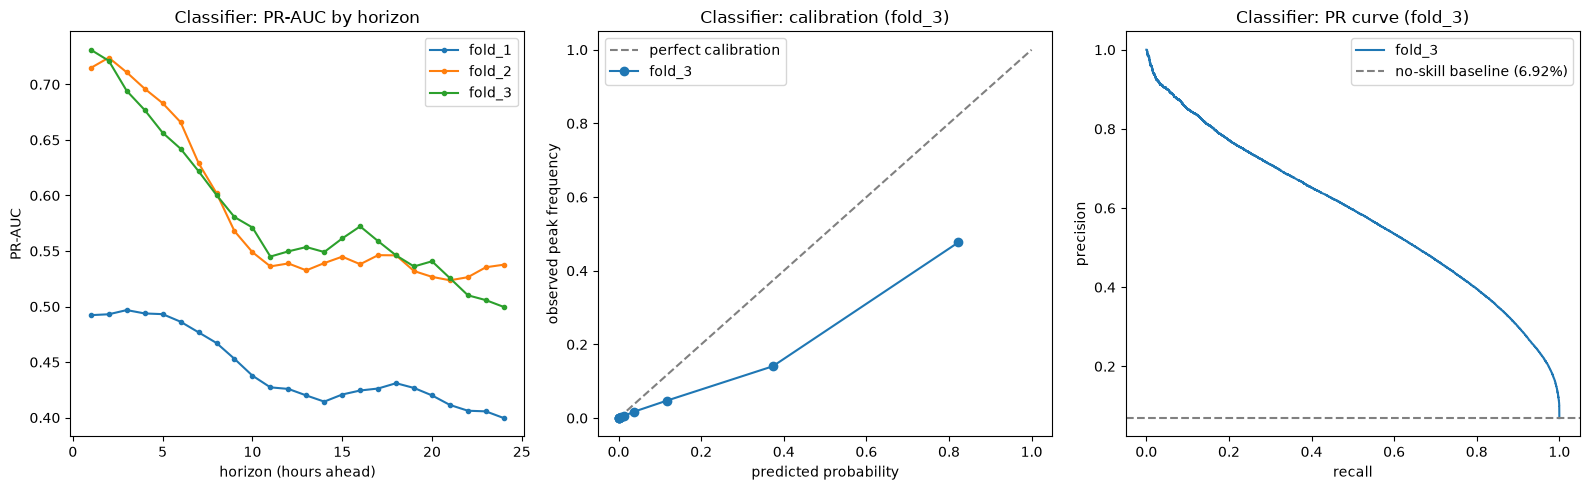

In [5]:
classifier_by_horizon = {}
for fold_name, results in classifier_results.items():
    rows = []
    for horizon, group in results.groupby("horizon"):
        row = peak_risk_metrics(group["actual_peak"], group["peak_probability"], group["predicted_peak"])
        row["horizon"] = horizon
        rows.append(row)
    classifier_by_horizon[fold_name] = pd.DataFrame(rows).set_index("horizon").sort_index()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for fold_name, metrics_df in classifier_by_horizon.items():
    axes[0].plot(metrics_df.index, metrics_df["pr_auc"], marker="o", markersize=3, label=fold_name)
axes[0].set_xlabel("horizon (hours ahead)")
axes[0].set_ylabel("PR-AUC")
axes[0].set_title("Classifier: PR-AUC by horizon")
axes[0].legend()

cal = calibration_data(classifier_results["fold_3"]["actual_peak"], classifier_results["fold_3"]["peak_probability"])
axes[1].plot([0, 1], [0, 1], linestyle="--", color="gray", label="perfect calibration")
axes[1].plot(cal["predicted_probability"], cal["observed_frequency"], marker="o", label="fold_3")
axes[1].set_xlabel("predicted probability")
axes[1].set_ylabel("observed peak frequency")
axes[1].set_title("Classifier: calibration (fold_3)")
axes[1].legend()

pr_curve = pr_curve_data(classifier_results["fold_3"]["actual_peak"], classifier_results["fold_3"]["peak_probability"])
axes[2].plot(pr_curve["recall"], pr_curve["precision"], label="fold_3")
base_rate = classifier_results["fold_3"]["actual_peak"].mean()
axes[2].axhline(base_rate, linestyle="--", color="gray", label=f"no-skill baseline ({base_rate:.2%})")
axes[2].set_xlabel("recall")
axes[2].set_ylabel("precision")
axes[2].set_title("Classifier: PR curve (fold_3)")
axes[2].legend()

fig.tight_layout()
plt.show()

In [6]:
r3 = classifier_results["fold_3"]
n = len(r3)
top_k = pd.DataFrame({
    "top_1pct": {"k": int(n * 0.01), "capture_rate": top_k_capture_rate(r3["actual_peak"], r3["peak_probability"], int(n * 0.01))},
    "top_5pct": {"k": int(n * 0.05), "capture_rate": top_k_capture_rate(r3["actual_peak"], r3["peak_probability"], int(n * 0.05))},
    "top_10pct": {"k": int(n * 0.10), "capture_rate": top_k_capture_rate(r3["actual_peak"], r3["peak_probability"], int(n * 0.10))},
}).T
top_k

,k,capture_rate
top_1pct,12579.0,0.120899
top_5pct,62899.0,0.450820
top_10pct,125798.0,0.689470


The same fold_1-weakest pattern as the regressor shows up again in PR-AUC, and the same horizon-degradation pattern too (steepest in fold_1 and fold_3, flatter after h12 in fold_2) - both already covered in `03_01_xgboost_classifier_training.ipynb`.

The PR curve (right panel) is new here - it's the full precision/recall tradeoff across every possible threshold, not just the single point the 0.5-threshold metrics table gives. The curve for fold_3 sits well above the no-skill baseline (6.9%, what precision would be if the model ranked hours at random) across most of the recall range, which is the clearest single visual confirmation that the classifier has real ranking skill. It also makes the earlier calibration finding easier to see in context: the curve doesn't reach anywhere near precision=1 even at low recall, consistent with `scale_pos_weight` trading calibrated probabilities for better separation.

Top-K: watching the riskiest 10% of hours in fold_3 catches about 69% of real peaks, versus roughly 10% from watching a random 10% - a meaningfully useful ranking for an operational "watch list" use case, even without a tuned decision threshold.

## 3. Final export

Concatenating all 3 folds' predictions into one table per model and saving them, each matching the team's required output schema exactly. Saved to `data/interim/results/` - generated, not versioned, same convention as `fsa_hourly_master.parquet`.

In [7]:
RESULTS_DIR = Path.cwd().parents[1] / "data" / "interim" / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

regressor_final = pd.concat(regressor_results.values(), ignore_index=True)
classifier_final = pd.concat(classifier_results.values(), ignore_index=True)

print("regressor required columns:", list(regressor_final.columns))
print("classifier columns (6 required + horizon extra):", list(classifier_final.columns))

regressor_final.to_csv(RESULTS_DIR / "xgboost_regressor_predictions.csv", index=False)
classifier_final.to_csv(RESULTS_DIR / "xgboost_classifier_predictions.csv", index=False)

print(f"saved {len(regressor_final):,} regressor rows and {len(classifier_final):,} classifier rows to {RESULTS_DIR}")

regressor required columns: ['FSA', 'origin_timestamp', 'forecast_timestamp', 'horizon', 'actual', 'prediction', 'model_name']
classifier columns (6 required + horizon extra): ['FSA', 'forecast_timestamp', 'actual_peak', 'peak_probability', 'predicted_peak', 'model_name', 'horizon']


saved 3,784,320 regressor rows and 3,784,320 classifier rows to C:\Tessy\Master of Data Analytics\TERM V\ontario-electricity-peak-risk\data\interim\results


## 4. Closing summary

Both models are pooled across the 6 FSAs, use the same 18 features, the same 3 expanding-window folds, and neither has had hyperparameter tuning - this is Model 3's first complete pass, not a tuned final version.

**Regressor:** WAPE around 6% on fold_2/fold_3, growing to about 7-8% by h+24. A check into whether that horizon growth comes from the persisted-weather assumption (origin's weather reused for all 24 hours) found it's only a partial explanation - even hours where the real weather barely changed still show most of the same error growth, so something else accumulating with horizon (likely general forecast uncertainty, not weather specifically) is the bigger contributor.

**Classifier:** PR-AUC around 0.58 on fold_2/fold_3, well above each fold's no-skill baseline. Two limitations worth carrying into the team comparison rather than hiding: the model is overconfident at high predicted probabilities (calibration, checked on fold_3), and the default 0.5 threshold over- or under-flags peaks inconsistently across folds - both are known, explainable consequences of `scale_pos_weight` rather than bugs, but neither has been corrected here.

**Common to both:** fold_1 is consistently the weakest fold, and this notebook can't cleanly say whether that's because it has the least training data or because 2023 itself is a harder year to predict - expanding window confounds those two things by design. A separate, informal diagnostic (fixed 2-year training window tested on 2025 instead of 2023) is planned to look into that, outside of this notebook.